In [1]:
#import libraries
import pandas as pd
import numpy as np
import math

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer, PowerTransformer
from sklearn.decomposition import PCA

import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
set_config(transform_output="pandas")

In [2]:
#import data
songs_df = pd.read_csv("3_spotify_5000_songs.csv")
songs_df.columns = songs_df.columns.str.strip()

# Exploratory Analysis

In [3]:
#check datatypes for consistency 
songs_df.dtypes

Unnamed: 0            int64
name                 object
artist               object
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
type                 object
duration_ms           int64
time_signature        int64
id                   object
html                 object
dtype: object

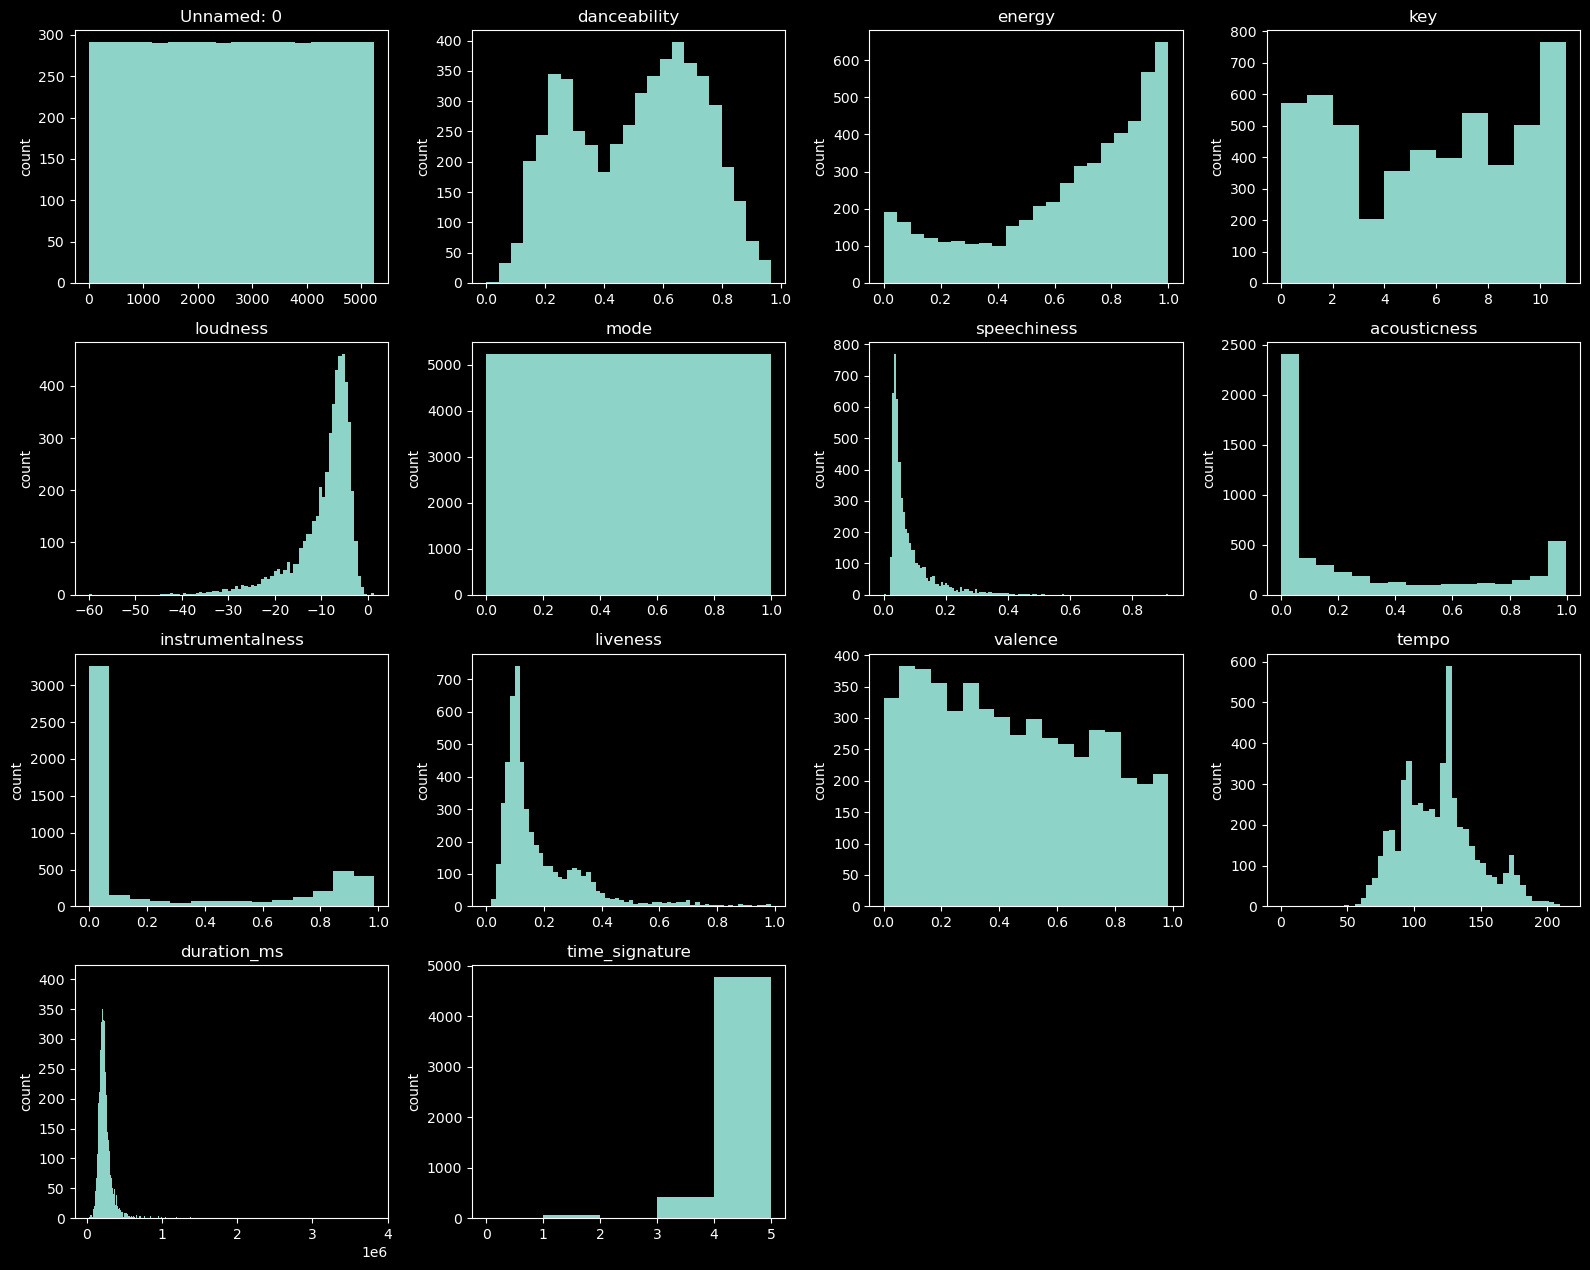

In [4]:
#histogram for data distribution

# Numeric columns only
num = songs_df.select_dtypes(include="number")

# Plot layout
plots_per_row = 4
n = num.shape[1]
rows = math.ceil(n / plots_per_row)

fig, axes = plt.subplots(rows, plots_per_row, figsize=(4 * plots_per_row, 3.2 * rows))
axes = axes.ravel()

for i, col in enumerate(num.columns):
    x = num[col].dropna().to_numpy()
    axes[i].hist(x, bins="auto")  
    axes[i].set_title(col)
    axes[i].set_ylabel("count")

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Cleaning dataframe

In [5]:
#clean data
songs_df.duplicated().sum()

np.int64(0)

In [6]:
#drop duplicated IDs
songs_df = songs_df.drop_duplicates(subset=["id"])

#drop duplicated combinations of song+artist
songs_df = songs_df.drop_duplicates(subset=["name", "artist"])

In [7]:
#keep dataframe with names as copy
songs_df = songs_df.set_index("id")
original = songs_df

#drop stringvalued columns, can't be used in clustering
#drop nominal columns, can't be used for rescaling
#drop duration because it does not describe the music itself
songs_df = songs_df.drop(columns=["Unnamed: 0", "artist", "html", "name", "type", "mode","key", "time_signature", "duration_ms"])

songs_df

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
id,,,,,,,,,
1n7JnwviZ7zf0LR1tcGFq7,0.6580,0.25900,-13.141,0.0705,0.694,0.000059,0.9750,0.3060,110.376
5QGM1U0eCYrQuwSJwTm5Zq,0.7420,0.39900,-12.646,0.0346,0.217,0.000002,0.1070,0.6930,125.039
0NLIFSZxPzQhCwnkn5PJYs,0.8510,0.73000,-11.048,0.3470,0.453,0.000063,0.1240,0.9050,93.698
3mXqOdlLE1k67WsAxryPFs,0.7050,0.05020,-18.115,0.0471,0.879,0.000041,0.3860,0.5240,106.802
7bSzjzjTkWT2CkIPPdp0eA,0.6510,0.11900,-19.807,0.0380,0.916,0.000343,0.1040,0.4020,120.941
...,...,...,...,...,...,...,...,...,...
1aEhYlZtypmipA06SDJ4U3,0.2020,0.06940,-23.390,0.0473,0.917,0.715000,0.0832,0.0655,87.906
1Gfqe7TAKklmuZf6hxsH6h,0.1880,0.10100,-21.873,0.0442,0.855,0.426000,0.0694,0.0355,83.134
2XNwnFrdMDpismp0VUZ7cU,0.0596,0.00093,-42.959,0.0434,0.951,0.969000,0.0772,0.0344,71.573


## Preparing data for clustering
Decide which transformer to use

### Rescale data features

In [8]:
#for loop to iterate through all scalers and check results

transliste = [MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer, PowerTransformer]
max_values_with_pca = []
for i in transliste:
    my_transformer = i()

    # Use the transformer to transform the data
    scaled_audiofeats_df = my_transformer.fit_transform(songs_df)


    # Initialise the PCA object
    pca = PCA()

    # Fit the PCA object to the data
    pca.fit(scaled_audiofeats_df)

    #extract explained variance to use in graph
    explained_audio_variance_array = pca.explained_variance_ratio_

    # Calculate the cumulative sum
    cumulative_sum = np.cumsum(explained_audio_variance_array)

    # Find the index where the cumulative sum reaches 0.95
    index = np.searchsorted(cumulative_sum, 0.95)

    # Print the number of components required to reach 0.95 variance
    pca_number = (index + 1)

    #create new dataframe of principal components

    pca_audio = PCA(n_components = pca_number)

    # Fit the PCA object to the scaled features dataframe and transform it
    pca_audio_df = pca_audio.fit_transform(scaled_audiofeats_df)



    # Create an empty list to store the silhouette scores
    sil_scores = []
    max_k = 150

    for k in range(20, max_k):

        # Create a KMeans object with the specified number of clusters
        kmeans = KMeans(n_clusters = k,
                        random_state = 42)

        # Fit the KMeans model to the scaled data
        kmeans.fit(pca_audio_df)

        # Get the cluster labels
        labels = kmeans.labels_

        # Calculate the silhouette score
        sil_score = silhouette_score(pca_audio_df, labels)

        # Append the silhouette score to the list
        sil_scores.append(sil_score)

    max_values_with_pca.append(max(sil_scores))

max_values_with_pca

[0.21175462396585246,
 0.1902514711539487,
 0.19781412417455982,
 0.1764722186940556,
 0.1807236791282642]

In [9]:
#scale audio features
#powertransformer performed well enough and is perfect for skewed data distribution
my_transformer = PowerTransformer()

# Use the transformer to transform the data
scaled_audiofeats_df = my_transformer.fit_transform(songs_df)

In [10]:
#check scaling of features
rangetable_scaled = scaled_audiofeats_df.max() - scaled_audiofeats_df.min()
rangetable_scaled

danceability         4.418504
energy               3.259520
loudness            12.592925
speechiness          5.161462
acousticness         2.546708
instrumentalness     2.323680
liveness             5.047172
valence              3.549206
tempo               10.625619
dtype: float64

### PCA on rescaled features to improve clustering

In [11]:
# Initialise the PCA object
pca = PCA()

# Fit the PCA object to the data
pca.fit(scaled_audiofeats_df)

#extract explained variance to use in graph
explained_audio_variance_array = pca.explained_variance_ratio_

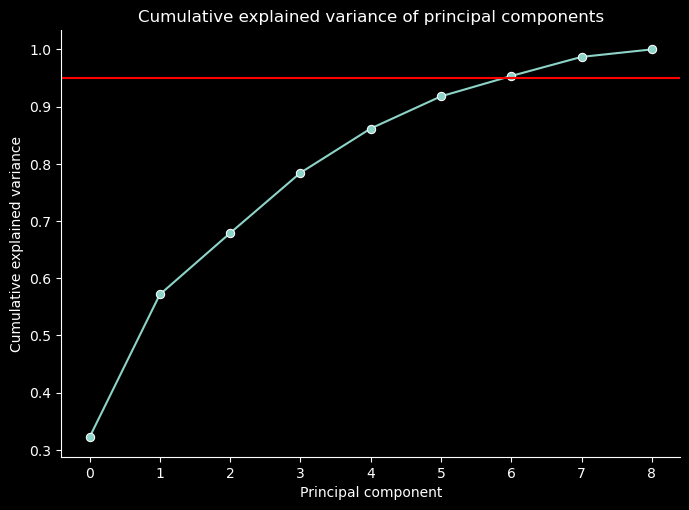

In [12]:
#plot variance to check necessary number of components

(
  # Create a cumulative explained variance plot
  sns.relplot(
      kind = "line",  # Create a line plot
      x = range(len(explained_audio_variance_array)),  # Set the x-axis to be the principal component index
      y = np.cumsum(explained_audio_variance_array),  # Set the y-axis to be the cumulative explained variance
      marker = "o",  # Use a circle marker for the data points
      aspect = 1.4,  # Set the aspect ratio of the plot to be 1.4
  )
  # Set the title of the plot
  .set(title = "Cumulative explained variance of principal components")
  # Set the axis labels
  .set_axis_labels("Principal component", "Cumulative explained variance")
);

# Add a horizontal red line at 0.95 on the y axis
plt.axhline(y = 0.95,
            color = 'red');

In [13]:
# Calculate the cumulative sum
cumulative_sum = np.cumsum(explained_audio_variance_array)

# Find the index where the cumulative sum reaches 0.95
index = np.searchsorted(cumulative_sum, 0.95)

# Print the number of components required to reach 0.95 variance
pca_number = (index + 1)
print(pca_number)

7


In [14]:
#create new dataframe of principal components

pca_audio = PCA(n_components = pca_number)

# Fit the PCA object to the scaled features dataframe and transform it
pca_audio_df = pca_audio.fit_transform(scaled_audiofeats_df)

# The dataframe now contains the principal components of the scaled features dataframe
pca_audio_df

,pca0,pca1,pca2,pca3,pca4,pca5,pca6
id,,,,,,,
1n7JnwviZ7zf0LR1tcGFq7,-1.115891,1.026287,2.029522,-1.104215,1.148624,-0.678813,0.160619
5QGM1U0eCYrQuwSJwTm5Zq,-0.594199,2.089197,-0.029871,0.595604,-0.183277,0.260615,-0.492819
0NLIFSZxPzQhCwnkn5PJYs,0.704207,1.710277,-0.842506,-1.286716,2.178489,0.554880,-0.353916
3mXqOdlLE1k67WsAxryPFs,-1.682568,1.955941,1.725559,-0.815099,0.805625,-0.087848,-0.261634
7bSzjzjTkWT2CkIPPdp0eA,-2.153602,1.912330,0.095161,0.489682,0.427770,-0.503819,-0.283917
...,...,...,...,...,...,...,...
1aEhYlZtypmipA06SDJ4U3,-3.941668,-0.832148,-0.665396,-0.234003,0.137019,-0.145651,0.089498
1Gfqe7TAKklmuZf6hxsH6h,-3.904674,-0.739529,-0.931923,-0.317198,-0.109994,-0.495716,0.009974
2XNwnFrdMDpismp0VUZ7cU,-4.946480,-1.192545,-0.862076,-0.666410,0.009710,-0.014365,-0.694054


## Cluster Analysis

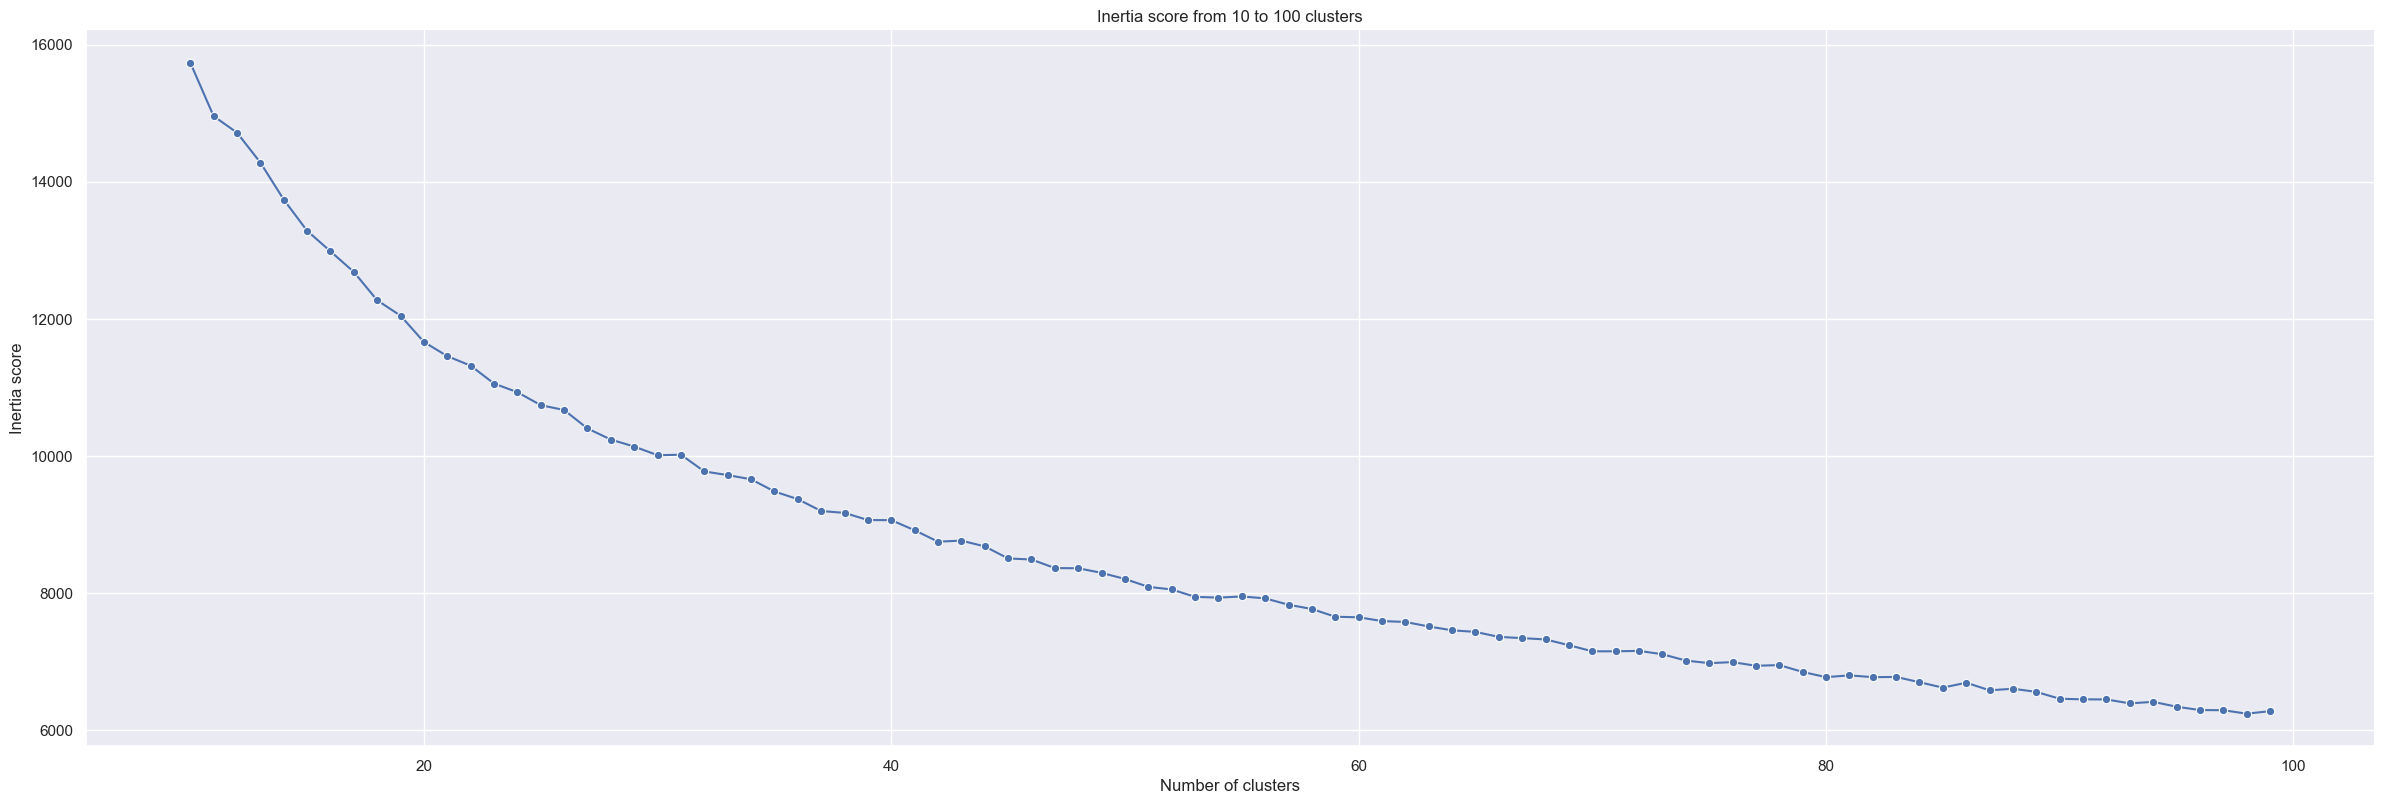

In [15]:
#create intertia list for elbow plot
inertia_list = []

for i in range(10,100):
    myKMeans = KMeans(n_clusters=i)
    myKMeans.fit(pca_audio_df)
    inertia_list.append(round(myKMeans.inertia_))

#elbow plot
# Set the Seaborn theme to darkgrid
sns.set_theme(style='darkgrid')

(
# Create a line plot of the inertia scores
sns.relplot(y = inertia_list,
            x = range(10, 100),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 3)
# Set the title of the plot
.set(title="Inertia score from 10 to 100 clusters")
# Set the axis labels
.set_axis_labels("Number of clusters", "Inertia score")
);

In [16]:
# elbow plot does not lend itself for interpretation
# check silhuette score

# Set the maximum number of clusters to try
max_k = 101

# Create an empty list to store the silhouette scores
sil_scores = []

for k in range(10, max_k):

    # Create a KMeans object with the specified number of clusters
    kmeans = KMeans(n_clusters = k,
                    random_state = 42)

    # Fit the KMeans model to the scaled data
    kmeans.fit(pca_audio_df)

    # Get the cluster labels
    labels = kmeans.labels_

    # Calculate the silhouette score
    sil_score = silhouette_score(pca_audio_df, labels)

    # Append the silhouette score to the list
    sil_scores.append(sil_score)

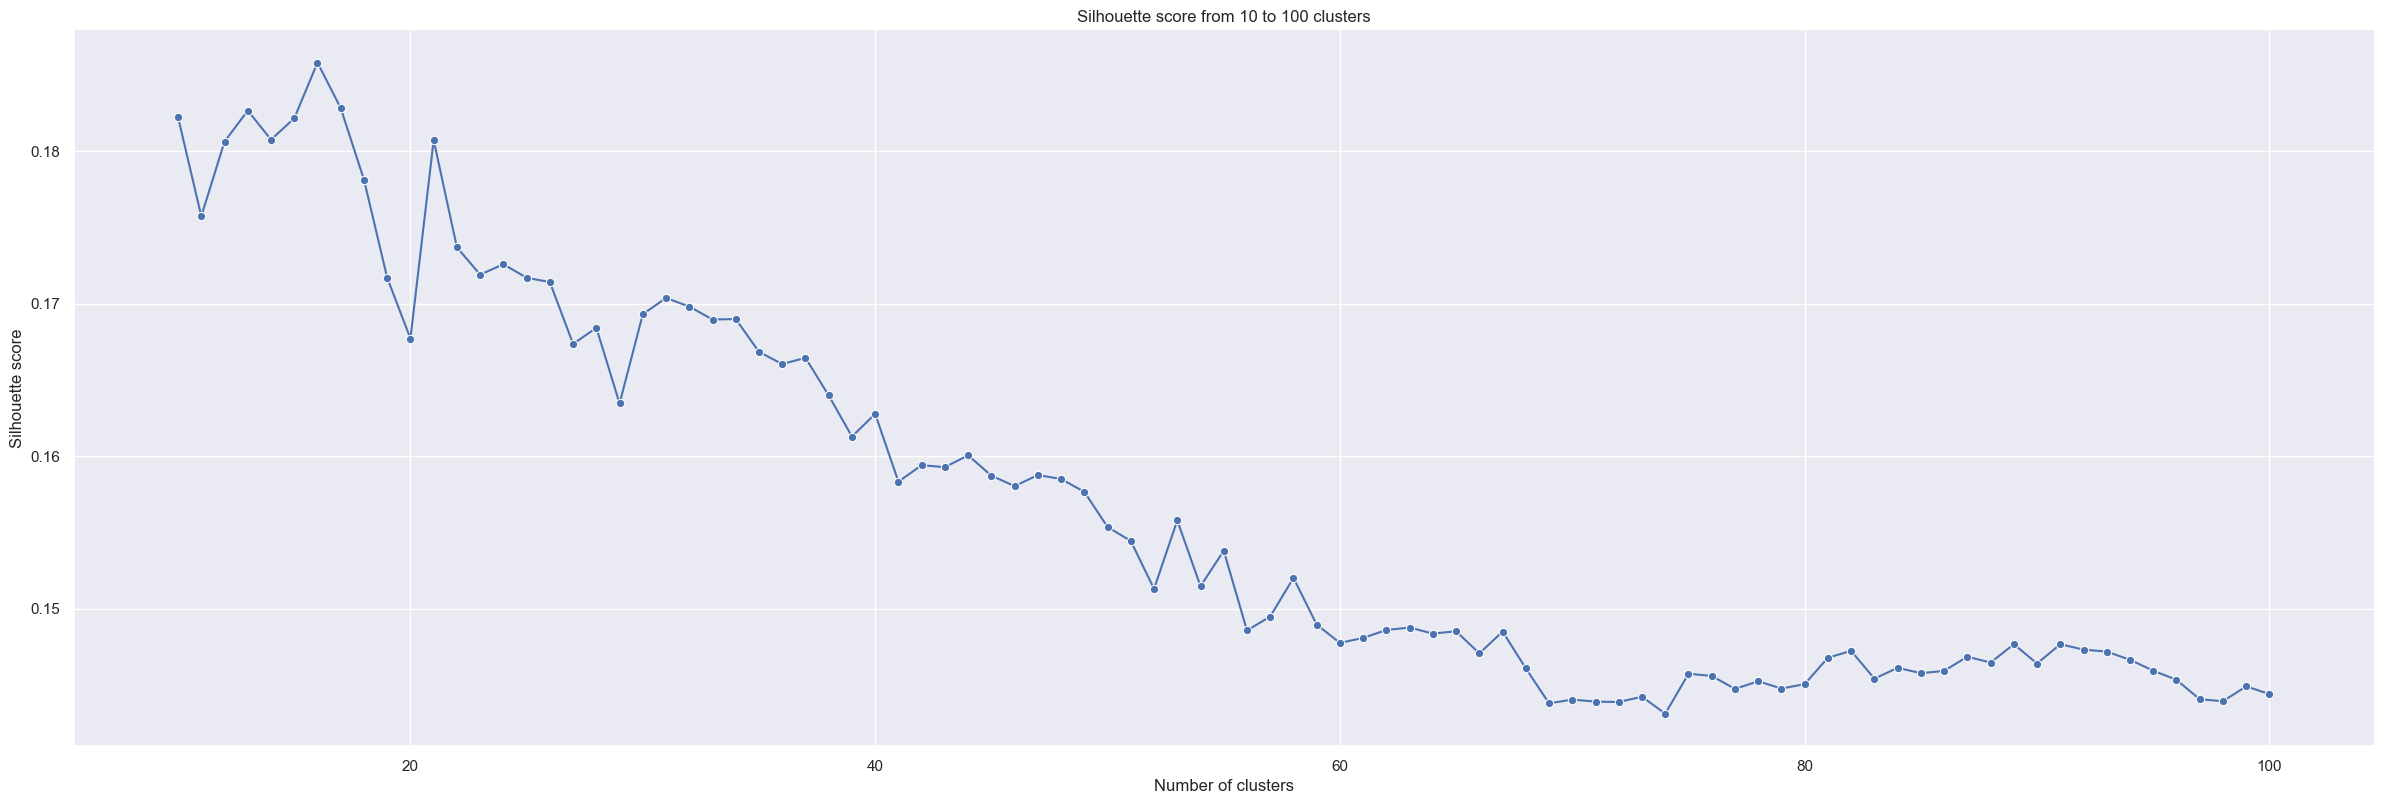

In [17]:
(
sns.relplot(y = sil_scores,
            x = range(10, max_k),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 3,)
.set(title=f"Silhouette score from 10 to {max_k - 1} clusters")
.set_axis_labels("Number of clusters", "Silhouette score")
);

## Create clusters for export of playlists

In [18]:
random_seed = 123

endgueltig_kmeans = KMeans(n_clusters = 21,
                      random_state = random_seed)

# 3. fit the model to the data
endgueltig_kmeans.fit(pca_audio_df)

,n_clusters,21
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,123
,copy_x,True
,algorithm,'lloyd'


In [19]:
#create cluster output

table = endgueltig_kmeans.labels_

# attach the cluster output to our original DataFrame
pca_audio_df["table"] = table

pca_audio_df = pca_audio_df.merge(original[["name", "artist"]], left_index=True, right_index=True, how="left").copy()
pca_audio_df

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,table,name,artist
id,,,,,,,,,,
1n7JnwviZ7zf0LR1tcGFq7,-1.115891,1.026287,2.029522,-1.104215,1.148624,-0.678813,0.160619,14,Se Eu Quiser Falar Com Deus ...,Gilberto Gil
5QGM1U0eCYrQuwSJwTm5Zq,-0.594199,2.089197,-0.029871,0.595604,-0.183277,0.260615,-0.492819,16,Saudade De Bahia ...,Antônio Carlos Jobim
0NLIFSZxPzQhCwnkn5PJYs,0.704207,1.710277,-0.842506,-1.286716,2.178489,0.554880,-0.353916,3,"Canta Canta, Minha Gente ...",Martinho Da Vila
3mXqOdlLE1k67WsAxryPFs,-1.682568,1.955941,1.725559,-0.815099,0.805625,-0.087848,-0.261634,14,Mulher Eu Sei ...,Chico César
7bSzjzjTkWT2CkIPPdp0eA,-2.153602,1.912330,0.095161,0.489682,0.427770,-0.503819,-0.283917,1,Rosa Morena ...,Kurt Elling
...,...,...,...,...,...,...,...,...,...,...
1aEhYlZtypmipA06SDJ4U3,-3.941668,-0.832148,-0.665396,-0.234003,0.137019,-0.145651,0.089498,5,"1812 Festival Overture, Op. 49: 1812 Overture,...",Pyotr Ilyich Tchaikovsky
1Gfqe7TAKklmuZf6hxsH6h,-3.904674,-0.739529,-0.931923,-0.317198,-0.109994,-0.495716,0.009974,5,"Winter Fragments pour ensemble instrumental, s...",Tristan Murail
2XNwnFrdMDpismp0VUZ7cU,-4.946480,-1.192545,-0.862076,-0.666410,0.009710,-0.014365,-0.694054,5,"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3...",Arnold Schoenberg


In [20]:
#create table
pca_audio_df = pca_audio_df.sort_values(by="table").copy()
pca_audio_df.drop(columns = pca_audio_df.columns[pca_audio_df.columns.str.startswith('pca')], inplace = True)
pca_audio_df

,table,name,artist
id,,,
5wwgYAs0uuIcV5bOzdUAaD,0,The Dead Half ...,Broken Hope
59ilR0QDH95L9tNmIZN5F3,0,Grind Box ...,Broken Hope
3U55wz9VuwskKq3FcGAxd3,0,Chewed To Stubs ...,Broken Hope
0nw9jNJCyXlkA5mY7Ech7V,0,Engorged With Impiety ...,Broken Hope
3zrNyH5cwdnBSo43HUczLO,0,Erotic Zoophilism ...,Broken Hope
...,...,...,...
5KU1H6mW4U4crmYhvy7Hpv,20,Desolation ...,Devastation
7w9bgPAmPTtrkt2v16QWvQ,20,"Lose Yourself - From ""8 Mile"" Soundtrack ...",Eminem
07LsO6WuJlpd2WssRy2yef,20,Dictated Deliverance ...,Morgoth


## Export Cluster result

In [21]:
#last check of cluster results
pca_audio_df.loc[pca_audio_df["table"] == 9]

,table,name,artist
id,,,
7wZorJD5loL9ceLJ67sg6S,9,Now That I've Found You (feat. John & Michel) ...,Martin Garrix
6WLS56xiRrXjSm9RSdL3zD,9,Never Forget You ...,Zara Larsson
2qT1uLXPVPzGgFOx4jtEuo,9,no tears left to cry ...,Ariana Grande
6LGpIWaJstYdRzGl1RE49z,9,Noch in 100.000 Jahren - Single Version ...,DJ Ötzi
3gzLYXBF3GWwj5Spy9iJbN,9,Das Schäferlied - Radio Version ...,Schäfer Heinrich
...,...,...,...
2dN72Xy0X05DiUXwtGAgCM,9,Party Like A Rock Star ...,Shop Boyz
3tvWMBIblzT5FSjKtIeRR1,9,Whatever You Like ...,T.I.
5XhkV07Vou38wnrzwURUOC,9,Who Am I (What's My Name)? ...,Snoop Dogg


In [ ]:
#save playlist
pca_audio_df.to_csv("playlists.csv", index=False)